In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/esm2-variant-benchmark'
predictions_path = f'{PROJECT_DIR}/data/processed/variants_with_predictions.tsv'

df = pd.read_csv(predictions_path, sep='\t')
print(f'{len(df)} variants loaded with predictions from all three models.')
df.head()


Mounted at /content/drive
6498 variants loaded with predictions from all three models.


,GeneSymbol,uniprot_accession,protein_change,label,ReviewStatus,PhenotypeList,position,conservation_score,wt_aa,mut_aa,esm2_score,prob_conservation,prob_esm2,prob_combined
0,PAH,P00439,Arg408Trp,1,reviewed by expert panel,Phenylketonuria|not provided|Inborn genetic di...,408,0.667587,R,W,-7.097335,0.640883,0.832142,0.815728
1,PAH,P00439,Leu311Pro,1,reviewed by expert panel,Phenylketonuria|not provided,311,0.737689,L,P,-10.732636,0.700338,0.966304,0.963419
2,PAH,P00439,Glu280Lys,1,"criteria provided, multiple submitters, no con...","Phenylketonuria|not provided|Polymicrogyria, p...",280,0.834147,E,K,-7.886076,0.769420,0.877777,0.892436
3,PAH,P00439,Arg261Gln,1,reviewed by expert panel,Phenylketonuria|not provided|PAH-related disorder,261,0.779125,R,Q,-4.044849,0.731483,0.553929,0.591617
4,PAH,P00439,Ser87Arg,1,reviewed by expert panel,Hyperphenylalaninemia|not provided|Phenylketon...,87,0.405575,S,R,-1.776208,0.398532,0.287943,0.208512


In [2]:
# Using 0.5 as the classification threshold for each model.
# A "discordant" variant is one where conservation and ESM-2 disagree
# on the predicted class -- these are the cases worth digging into.
df['pred_conservation'] = (df['prob_conservation'] >= 0.5).astype(int)
df['pred_esm2'] = (df['prob_esm2'] >= 0.5).astype(int)

df['conservation_correct'] = (df['pred_conservation'] == df['label'])
df['esm2_correct'] = (df['pred_esm2'] == df['label'])

esm2_wins = df[(df['esm2_correct']) & (~df['conservation_correct'])]
conservation_wins = df[(df['conservation_correct']) & (~df['esm2_correct'])]
both_wrong = df[(~df['esm2_correct']) & (~df['conservation_correct'])]
both_right = df[(df['esm2_correct']) & (df['conservation_correct'])]

print(f'Both correct: {len(both_right)} ({len(both_right)/len(df)*100:.1f}%)')
print(f'ESM-2 correct, conservation wrong: {len(esm2_wins)} ({len(esm2_wins)/len(df)*100:.1f}%)')
print(f'Conservation correct, ESM-2 wrong: {len(conservation_wins)} ({len(conservation_wins)/len(df)*100:.1f}%)')
print(f'Both wrong: {len(both_wrong)} ({len(both_wrong)/len(df)*100:.1f}%)')

Both correct: 4167 (64.1%)
ESM-2 correct, conservation wrong: 1372 (21.1%)
Conservation correct, ESM-2 wrong: 452 (7.0%)
Both wrong: 507 (7.8%)


In [3]:
# See if ESM-2's wins are spread evenly across proteins or concentrated
# in specific genes -- this often points to something biologically
# interpretable (e.g. proteins with sparse evolutionary sampling).
gene_breakdown = pd.DataFrame({
    'esm2_wins': esm2_wins.groupby('GeneSymbol').size(),
    'conservation_wins': conservation_wins.groupby('GeneSymbol').size(),
    'both_right': both_right.groupby('GeneSymbol').size(),
    'both_wrong': both_wrong.groupby('GeneSymbol').size()
}).fillna(0).astype(int)

gene_breakdown['esm2_advantage'] = gene_breakdown['esm2_wins'] - gene_breakdown['conservation_wins']
gene_breakdown = gene_breakdown.sort_values('esm2_advantage', ascending=False)
print(gene_breakdown)

            esm2_wins  conservation_wins  both_right  both_wrong  \
GeneSymbol                                                         
BRCA2             386                 20         256         117   
BRCA1             349                 21         232          36   
FBN1              205                 11        1077          16   
TP53              109                 30         129          12   
PTEN               54                  2         171           1   
ATM                40                  7         145          26   
COL1A1             36                 11         450          25   
MLH1               34                 13         154          12   
VHL                14                  3         138          18   
BRAF                8                  3         103           0   
RB1                12                 10          42           4   
LDLR               35                 34         464          39   
APOE                5                  5        

Correlation between conservation_score and esm2_score: -0.421


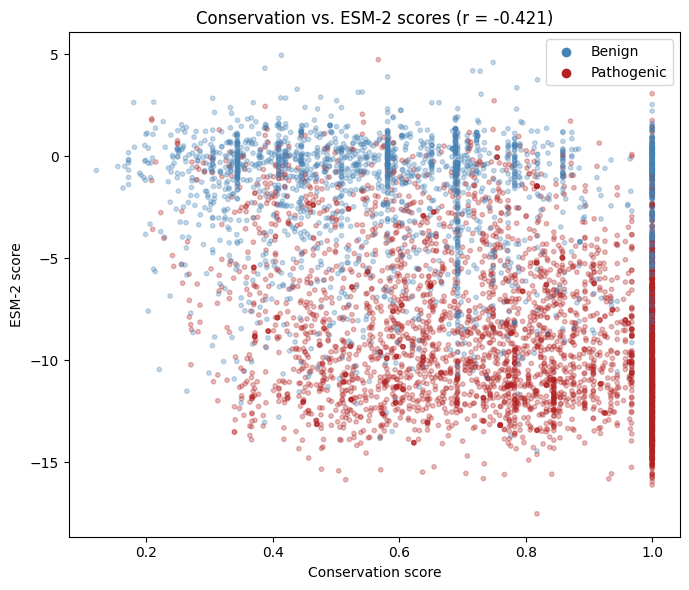

In [4]:
# If conservation_score and esm2_score were highly correlated, that would
# explain why WP4's "combined" model barely beat ESM-2 alone -- the two
# signals overlap heavily rather than being complementary.
correlation = df['conservation_score'].corr(df['esm2_score'])
print(f'Correlation between conservation_score and esm2_score: {correlation:.3f}')

plt.figure(figsize=(7, 6))
colors = df['label'].map({0: 'steelblue', 1: 'firebrick'})
plt.scatter(df['conservation_score'], df['esm2_score'], c=colors, alpha=0.3, s=10)
plt.xlabel('Conservation score')
plt.ylabel('ESM-2 score')
plt.title(f'Conservation vs. ESM-2 scores (r = {correlation:.3f})')
plt.scatter([], [], c='steelblue', label='Benign')
plt.scatter([], [], c='firebrick', label='Pathogenic')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/score_correlation.png', dpi=150)
plt.show()

In [5]:
# The interesting biological story: these are pathogenic variants at
# positions that are NOT well conserved by classical measures, but ESM-2
# still correctly flags as damaging -- likely because it's picking up on
# structural or functional context beyond simple sequence conservation.
esm2_wins_pathogenic = esm2_wins[esm2_wins['label'] == 1]
print(f'{len(esm2_wins_pathogenic)} pathogenic variants that ESM-2 caught but conservation missed.')
print()
print('Their conservation scores (should be low/moderate -- that\'s WHY conservation missed them):')
print(esm2_wins_pathogenic['conservation_score'].describe())
print()
print('Compare to conservation scores of pathogenic variants conservation DID catch:')
conservation_correct_pathogenic = df[(df['label'] == 1) & (df['conservation_correct'])]
print(conservation_correct_pathogenic['conservation_score'].describe())

387 pathogenic variants that ESM-2 caught but conservation missed.

Their conservation scores (should be low/moderate -- that's WHY conservation missed them):
count    387.000000
mean       0.425561
std        0.062000
min        0.228210
25%        0.374154
50%        0.443973
75%        0.476550
max        0.512577
Name: conservation_score, dtype: float64

Compare to conservation scores of pathogenic variants conservation DID catch:
count    3840.000000
mean        0.849936
std         0.158203
min         0.509891
25%         0.725034
50%         0.891706
75%         1.000000
max         1.000000
Name: conservation_score, dtype: float64


In [6]:
# Pull out the clearest individual cases for a table/example in your paper --
# variants where ESM-2 was very confident and correct, conservation very
# confident and wrong.
interesting_cases = esm2_wins.copy()
interesting_cases['esm2_confidence'] = np.abs(interesting_cases['prob_esm2'] - 0.5)
interesting_cases = interesting_cases.sort_values('esm2_confidence', ascending=False)

display_cols = ['GeneSymbol', 'protein_change', 'label', 'conservation_score',
                 'esm2_score', 'prob_conservation', 'prob_esm2']
print('Top 10 clearest cases where ESM-2 succeeded and conservation failed:')
interesting_cases[display_cols].head(10)

Top 10 clearest cases where ESM-2 succeeded and conservation failed:


,GeneSymbol,protein_change,label,conservation_score,esm2_score,prob_conservation,prob_esm2
4928,MSH2,Leu270Arg,1,0.504474,-15.413039,0.491577,0.995965
1752,PTEN,His141Pro,1,0.477198,-15.327190,0.465473,0.995906
2978,FBN1,Cys652Trp,1,0.456884,-14.782335,0.452730,0.994817
3338,PTEN,Leu181Pro,1,0.441552,-14.325275,0.434235,0.993743
3624,FBN1,Leu2815His,1,0.479625,-14.244421,0.469493,0.993500
2610,PTEN,Val166Glu,1,0.477434,-14.308146,0.472182,0.993024
3831,FBN1,Cys359Phe,1,0.506271,-13.875606,0.494373,0.992263
5111,FBN1,Gly234Cys,1,0.480545,-13.872993,0.470350,0.992254
4362,MSH2,Ile411Arg,1,0.508103,-13.908798,0.499947,0.992210
4095,FBN1,Cys2663Phe,1,0.447174,-13.908155,0.443848,0.992208


In [7]:
os.makedirs(f'{PROJECT_DIR}/results/tables', exist_ok=True)

gene_breakdown.to_csv(f'{PROJECT_DIR}/results/tables/gene_level_breakdown.tsv', sep='\t')
interesting_cases[display_cols].head(20).to_csv(
    f'{PROJECT_DIR}/results/tables/top_discordant_cases.tsv', sep='\t', index=False
)

summary = pd.DataFrame([{
    'both_correct': len(both_right),
    'esm2_only_correct': len(esm2_wins),
    'conservation_only_correct': len(conservation_wins),
    'both_wrong': len(both_wrong),
    'score_correlation': correlation
}])
summary.to_csv(f'{PROJECT_DIR}/results/tables/error_analysis_summary.tsv', sep='\t', index=False)

print('Saved gene_level_breakdown.tsv, top_discordant_cases.tsv, error_analysis_summary.tsv')
summary

Saved gene_level_breakdown.tsv, top_discordant_cases.tsv, error_analysis_summary.tsv


,both_correct,esm2_only_correct,conservation_only_correct,both_wrong,score_correlation
0,4167,1372,452,507,-0.420553


In [8]:
# The flip side of Cell 5/6: pathogenic variants that conservation caught
# but ESM-2 missed. If these cluster at very deeply conserved positions,
# it suggests ESM-2 sometimes underweights extremely strong cross-species
# conservation signal -- a useful, balanced point for the discussion.
conservation_wins_pathogenic = conservation_wins[conservation_wins['label'] == 1]
print(f'{len(conservation_wins_pathogenic)} pathogenic variants that conservation caught but ESM-2 missed.')
print()
print('Their ESM-2 scores (should be weak/ambiguous -- that\'s WHY ESM-2 missed them):')
print(conservation_wins_pathogenic['esm2_score'].describe())
print()
print('Compare to ESM-2 scores of pathogenic variants ESM-2 DID catch:')
esm2_correct_pathogenic = df[(df['label'] == 1) & (df['esm2_correct'])]
print(esm2_correct_pathogenic['esm2_score'].describe())
print()

# Gene pattern for these cases, same style as before
interesting_conservation_cases = conservation_wins.copy()
interesting_conservation_cases['conservation_confidence'] = np.abs(
    interesting_conservation_cases['prob_conservation'] - 0.5
)
interesting_conservation_cases = interesting_conservation_cases.sort_values(
    'conservation_confidence', ascending=False
)

display_cols = ['GeneSymbol', 'protein_change', 'label', 'conservation_score',
                 'esm2_score', 'prob_conservation', 'prob_esm2']
print('Top 10 clearest cases where conservation succeeded and ESM-2 failed:')
interesting_conservation_cases[display_cols].head(10)

312 pathogenic variants that conservation caught but ESM-2 missed.

Their ESM-2 scores (should be weak/ambiguous -- that's WHY ESM-2 missed them):
count    312.000000
mean      -1.610269
std        1.403138
min       -3.683809
25%       -2.733081
50%       -1.824733
75%       -0.702095
max        4.730687
Name: esm2_score, dtype: float64

Compare to ESM-2 scores of pathogenic variants ESM-2 DID catch:
count    3915.000000
mean       -9.851974
std         2.686224
min       -17.513733
25%       -11.852956
50%       -10.305171
75%        -7.865610
max        -3.645648
Name: esm2_score, dtype: float64

Top 10 clearest cases where conservation succeeded and ESM-2 failed:


,GeneSymbol,protein_change,label,conservation_score,esm2_score,prob_conservation,prob_esm2
185,HBB,Val110Leu,1,1.0,-2.338283,0.864865,0.345257
189,HBB,Ala28Ser,1,1.0,-3.170288,0.864865,0.438551
170,HBB,Lys145Asn,1,1.0,-1.378901,0.864865,0.251050
195,HBB,Asn20Ser,1,1.0,-3.036423,0.864865,0.423051
946,BRCA1,Met1411Thr,1,1.0,-2.861768,0.864865,0.403058
5828,TP53,Asn239Lys,1,1.0,1.435824,0.864865,0.081490
3750,KRAS,Met72Leu,1,1.0,-3.465593,0.864865,0.473129
2446,KRAS,Lys147Arg,1,1.0,-2.326881,0.864865,0.344040
1898,BRCA1,Arg1495Thr,1,1.0,0.672804,0.864865,0.112852
2255,TP53,Gly244Ser,1,1.0,-1.896501,0.864865,0.299730


In [9]:
interesting_conservation_cases[display_cols].head(20).to_csv(
    f'{PROJECT_DIR}/results/tables/top_conservation_wins_cases.tsv', sep='\t', index=False
)
print('Saved top_conservation_wins_cases.tsv')

Saved top_conservation_wins_cases.tsv
